In [1]:
!pip install iisignature

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iisignature: filename=iisignature-0.24-cp311-cp311-linux_x86_64.whl size=3246078 sha256=44ce90574b582f1bcbc38256c6cb05dde1b159892001ba63c6ff24cbcfb22dc4
  Stored in directory: /root/.cache/pip/wheels/1c/f4/57/0b4d3787a07f20a3cd1a91835d6247f55ef899345267bcd6df
Successfully built iisignature


Step 1: Generating 'Real' Data from GBM...

Step 2: Building the Signature Library...


Building Library: 100%|██████████| 200/200 [00:00<00:00, 1670.17it/s]



Step 3: Simulating New Paths with k-NN Generator...


Generating Paths: 100%|██████████| 20/20 [00:01<00:00, 16.71it/s]



Step 4: Checking if Distributions Match using MMD Test...


Running Permutation Test: 100%|██████████| 500/500 [00:00<00:00, 1967.31it/s]



--- Test Results ---
MMD^2 Statistic: -0.000320
P-value: 0.3640
Conclusion: We FAIL to reject the null hypothesis.
The distribution of simulated paths is statistically SIMILAR to the real GBM paths.


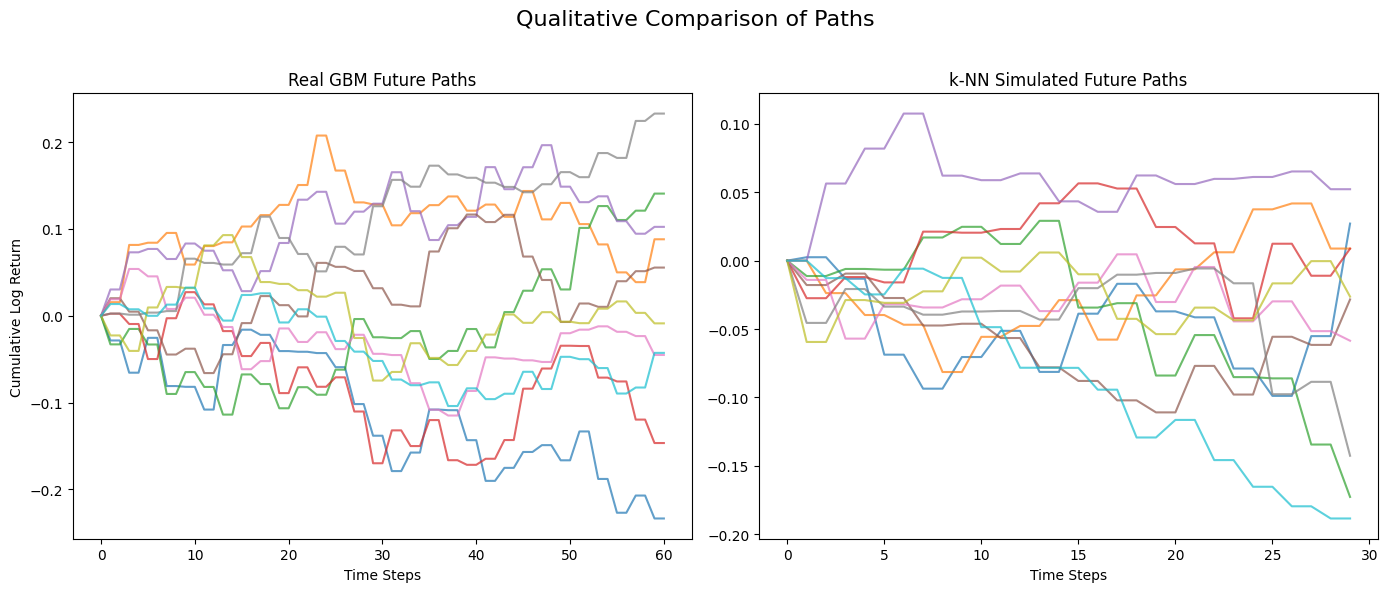

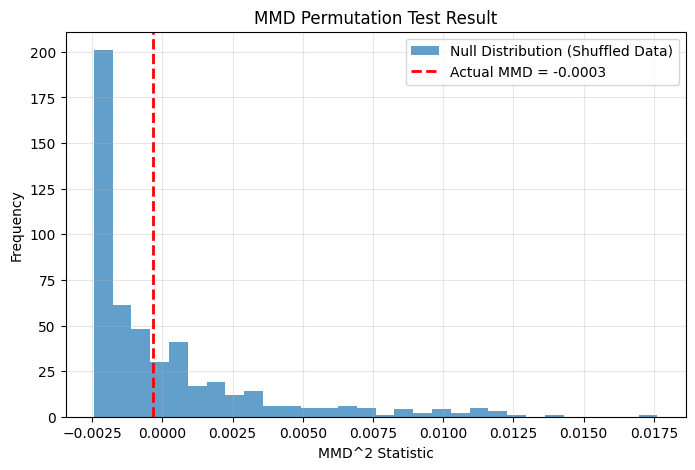

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import iisignature
from tqdm import tqdm

# --- Part 1: Data Generation (The "True" Process) ---

def generate_gbm_paths(n_paths, n_steps, mu, sigma, S0=1.0):
    """
    Generates paths from a Geometric Brownian Motion SDE.
    Returns paths of prices.
    """
    dt = 1.0 / n_steps
    # Generate random shocks
    Z = np.random.normal(0.0, np.sqrt(dt), size=(n_paths, n_steps))
    # Euler-Maruyama scheme for the log-price SDE
    log_S = np.zeros((n_paths, n_steps + 1))
    log_S[:, 0] = np.log(S0)

    for t in range(1, n_steps + 1):
        log_S[:, t] = log_S[:, t - 1] + (mu - 0.5 * sigma**2) * dt + sigma * Z[:, t - 1]

    return np.exp(log_S)

def generate_cev_paths(n_paths, n_steps, mu, sigma, gamma, S0=1.0):
    """
    Generates paths from a Constant Elasticity of Variance (CEV) SDE.
    Includes an absorbing boundary at zero for stability.
    """
    dt = 1.0 / n_steps
    # Generate random shocks
    Z = np.random.normal(0.0, np.sqrt(dt), size=(n_paths, n_steps))
    S = np.zeros((n_paths, n_steps + 1))
    S[:, 0] = S0

    for t in range(1, n_steps + 1):
        # Previous price, ensuring it's not negative from a previous unstable step
        S_prev = np.maximum(S[:, t - 1], 0)

        # Euler-Maruyama scheme for CEV
        drift = mu * S_prev * dt
        diffusion = sigma * (S_prev ** gamma) * Z[:, t - 1]

        S[:, t] = S_prev + drift + diffusion

    # Ensure all prices in the final path are non-negative
    S = np.maximum(S, 1e-5)

    return S

def generate_gmr_paths(n_paths, n_steps, kappa, theta, sigma, S0=1.0):
    """
    Generates paths from a Geometric Mean-Reverting (Ornstein-Uhlenbeck) process.
    """
    dt = 1.0 / n_steps
    # Generate random shocks
    Z = np.random.normal(0.0, np.sqrt(dt), size=(n_paths, n_steps))

    # Simulate the log-price process X_t = log(S_t)
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = np.log(S0)

    for t in range(1, n_steps + 1):
        # Euler-Maruyama scheme for the OU process
        X_prev = X[:, t - 1]
        drift = kappa * (theta - X_prev) * dt
        diffusion = sigma * Z[:, t - 1]

        X[:, t] = X_prev + drift + diffusion

    # Exponentiate to get the price path S_t
    return np.exp(X)

# --- Part 2: Path Preprocessing and Library Creation ---

def preprocess_paths(price_paths):
    """
    Converts price paths into our desired input format:
    1. Log returns
    2. Lead-lag transformed paths
    This version includes checks for numerical stability.
    """
    processed = []
    for p in price_paths:
        # --- ROBUSTNESS CHECK ---
        # If any price is zero or negative, the path is numerically unstable.
        # We will skip it entirely to avoid errors.
        if np.any(p <= 0):
            # You could print a warning here if you want to know how often this happens
            # print("Warning: Skipping a path due to non-positive prices.")
            continue  # Go to the next path in the loop

        # 1. Calculate log returns
        # This is now safe because we've ensured p > 0
        log_returns = np.log(p[1:] / p[:-1])

        # 2. Perform lead-lag transform on the cumulative log returns
        cumulative_log_returns = np.insert(np.cumsum(log_returns), 0, 0)

        repeated = np.repeat(cumulative_log_returns, 2)
        lead = repeated[1:]
        lag = repeated[:-1]

        processed.append(np.stack([lead, lag], axis=1))

    return processed

def create_path_library(processed_paths, n_lookback, m_forecast, sig_level):
    """
    Creates the library of (past_signature, future_path) pairs.
    Assumes paths are ALREADY preprocessed.
    This version correctly stores relative future paths.
    """
    library = []
    total_window = n_lookback + m_forecast

    for processed_path in tqdm(processed_paths, desc="Building Library"):
        for i in range(len(processed_path) - total_window + 1):
            past_path = processed_path[i : i + n_lookback]

            # Slice the absolute future path from the long processed path
            future_path_absolute = processed_path[i + n_lookback : i + total_window]

            # --- THE FIX: Re-base the future path to start at 0 ---
            start_point = future_path_absolute[0].copy() # Get the starting coordinate
            future_path_relative = future_path_absolute - start_point

            # Compute the signature of the past
            past_signature = iisignature.sig(past_path, sig_level)

            # Store the signature and the RELATIVE future path
            library.append({'signature': past_signature, 'future': future_path_relative})

    return library

# --- Part 3: The k-NN Generative Model ---

def generate_new_paths(start_paths, library, k, sig_level):
    """
    Generates new paths using the k-NN method on the signature library.
    """
    simulated_paths = []

    # Preprocess the starting paths
    processed_starts = preprocess_paths(start_paths)

    for start_path in tqdm(processed_starts, desc="Generating Paths"):
        # Calculate the signature of the current situation
        current_sig = iisignature.sig(start_path, sig_level)

        # --- The Kernel Step: Find distances to all library signatures ---
        # We use squared Euclidean distance, which is related to the kernel.
        # k(x,y) = <x,y>. ||x-y||^2 = <x,x> - 2<x,y> + <y,y>
        # Maximizing the kernel value is equivalent to minimizing the distance.
        distances = [np.linalg.norm(current_sig - item['signature']) for item in library]

        # Get the indices of the k-nearest neighbors
        knn_indices = np.argsort(distances)[:k]

        # --- The Generative Step: Randomly sample a future ---
        # Pick one of the k-nearest futures at random
        chosen_neighbor_index = np.random.choice(knn_indices)
        simulated_future = library[chosen_neighbor_index]['future']

        simulated_paths.append(simulated_future)

    return simulated_paths


# --- Part 4: The MMD Two-Sample Test ---

def calculate_mmd(paths_A, paths_B, sig_level):
    """
    Calculates the Maximum Mean Discrepancy (MMD) statistic between two
    sets of paths using the signature kernel.
    """
    # Pre-compute all signatures for efficiency
    sigs_A = [iisignature.sig(p, sig_level) for p in paths_A]
    sigs_B = [iisignature.sig(p, sig_level) for p in paths_B]

    n = len(sigs_A)
    m = len(sigs_B)

    # Calculate Gram matrices (containing all pairwise dot products)
    gram_AA = np.dot(np.array(sigs_A), np.array(sigs_A).T)
    gram_BB = np.dot(np.array(sigs_B), np.array(sigs_B).T)
    gram_AB = np.dot(np.array(sigs_A), np.array(sigs_B).T)

    # Calculate the three terms of the MMD^2 formula
    # We exclude the diagonal terms (i==j) for the unbiased estimator
    term_A = (np.sum(gram_AA) - np.trace(gram_AA)) / (n * (n - 1))
    term_B = (np.sum(gram_BB) - np.trace(gram_BB)) / (m * (m - 1))
    term_AB = np.mean(gram_AB)

    return term_A + term_B - 2 * term_AB

def permutation_test(paths_A, paths_B, sig_level, n_permutations=500):
    """
    Performs a permutation test to assess the significance of the MMD.
    """
    # Calculate the MMD for the original samples
    real_mmd = calculate_mmd(paths_A, paths_B, sig_level)

    # Pool all paths together
    all_paths = paths_A + paths_B
    n_A = len(paths_A)

    permuted_mmds = []
    for _ in tqdm(range(n_permutations), desc="Running Permutation Test"):
        # Shuffle the pooled paths
        np.random.shuffle(all_paths)
        # Create new fake sets
        perm_A = all_paths[:n_A]
        perm_B = all_paths[n_A:]
        # Calculate MMD for the permuted sets
        permuted_mmds.append(calculate_mmd(perm_A, perm_B, sig_level))

    # The p-value is the proportion of permuted MMDs that are >= the real MMD
    p_value = np.mean(np.array(permuted_mmds) >= real_mmd)

    return real_mmd, p_value, permuted_mmds

# --- Part 5: Main Execution ---

if __name__ == '__main__':
    # --- Model & Simulation Parameters ---
    # GBM Parameters
    mu = 0.05
    sigma = 0.2
    S0 = 100

    # Path Parameters
    n_steps_lookback = 30  # N
    n_steps_forecast = 30   # M

    # Model Hyperparameters
    SIGNATURE_LEVEL = 3    # m
    K_NEIGHBORS = 10       # k

    # --- Data Generation ---
    print("Step 1: Generating 'Real' Data from GBM...")
    n_library_paths = 200
    n_test_paths = 20
    total_steps_needed = n_steps_lookback + n_steps_forecast

    library_gbm_paths = generate_gbm_paths(n_library_paths, total_steps_needed, mu, sigma, S0)
    test_gbm_paths = generate_gbm_paths(n_test_paths, total_steps_needed, mu, sigma, S0)

    # --- Library Creation ---
    print("\nStep 2: Building the Signature Library...")
    # We preprocess the price paths into lead-lag paths of cumulative log returns
    processed_library_paths = preprocess_paths(library_gbm_paths)
    path_library = create_path_library(processed_library_paths, n_steps_lookback, n_steps_forecast, SIGNATURE_LEVEL)

    # --- Simulation ---
    print("\nStep 3: Simulating New Paths with k-NN Generator...")
    # We use the first part of the test set as starting points for our simulation
    start_paths_for_sim = test_gbm_paths[:, :n_steps_lookback + 1]
    simulated_paths = generate_new_paths(start_paths_for_sim, path_library, K_NEIGHBORS, SIGNATURE_LEVEL)

    # The "true" futures that correspond to our starting paths
    real_future_paths = preprocess_paths(test_gbm_paths[:, n_steps_lookback:])

    # --- Validation with MMD Test ---
    print("\nStep 4: Checking if Distributions Match using MMD Test...")
    mmd_value, p_value, null_distribution = permutation_test(
        real_future_paths,
        simulated_paths,
        SIGNATURE_LEVEL
    )

    print(f"\n--- Test Results ---")
    print(f"MMD^2 Statistic: {mmd_value:.6f}")
    print(f"P-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusion: We FAIL to reject the null hypothesis.")
        print("The distribution of simulated paths is statistically SIMILAR to the real GBM paths.")
    else:
        print("Conclusion: We REJECT the null hypothesis.")
        print("The distribution of simulated paths is statistically DIFFERENT from the real GBM paths.")

    # --- Visualization ---
    # 1. Plot some example paths
    plt.figure(figsize=(14, 6))
    plt.suptitle('Qualitative Comparison of Paths', fontsize=16)

    ax1 = plt.subplot(1, 2, 1)
    for i in range(10):
        # To plot, we need to convert back to a 1D cumulative return path
        path_1d = real_future_paths[i][:, 0]
        ax1.plot(path_1d, alpha=0.7)
    ax1.set_title('Real GBM Future Paths')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Cumulative Log Return')

    ax2 = plt.subplot(1, 2, 2)
    for i in range(10):
        path_1d = simulated_paths[i][:, 0]
        ax2.plot(path_1d, alpha=0.7)
    ax2.set_title('k-NN Simulated Future Paths')
    ax2.set_xlabel('Time Steps')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # 2. Plot the MMD test result
    plt.figure(figsize=(8, 5))
    plt.hist(null_distribution, bins=30, alpha=0.7, label='Null Distribution (Shuffled Data)')
    plt.axvline(mmd_value, color='red', linestyle='--', linewidth=2, label=f'Actual MMD = {mmd_value:.4f}')
    plt.title('MMD Permutation Test Result')
    plt.xlabel('MMD^2 Statistic')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Step 1: Generating 'Real' Data from CEV model...

Step 2: Building the Signature Library...


Building Library: 100%|██████████| 500/500 [00:00<00:00, 3576.98it/s]



Step 3: Simulating New Paths with k-NN Generator...


Generating Paths: 100%|██████████| 20/20 [00:01<00:00, 12.38it/s]



Step 4: Checking if Distributions Match using MMD Test...


Running Permutation Test: 100%|██████████| 500/500 [00:00<00:00, 1592.28it/s]



--- Test Results ---
MMD^2 Statistic: 0.411683
P-value: 0.0560
Conclusion: We FAIL to reject the null hypothesis.
The distribution of simulated paths is statistically SIMILAR to the real CEV paths.


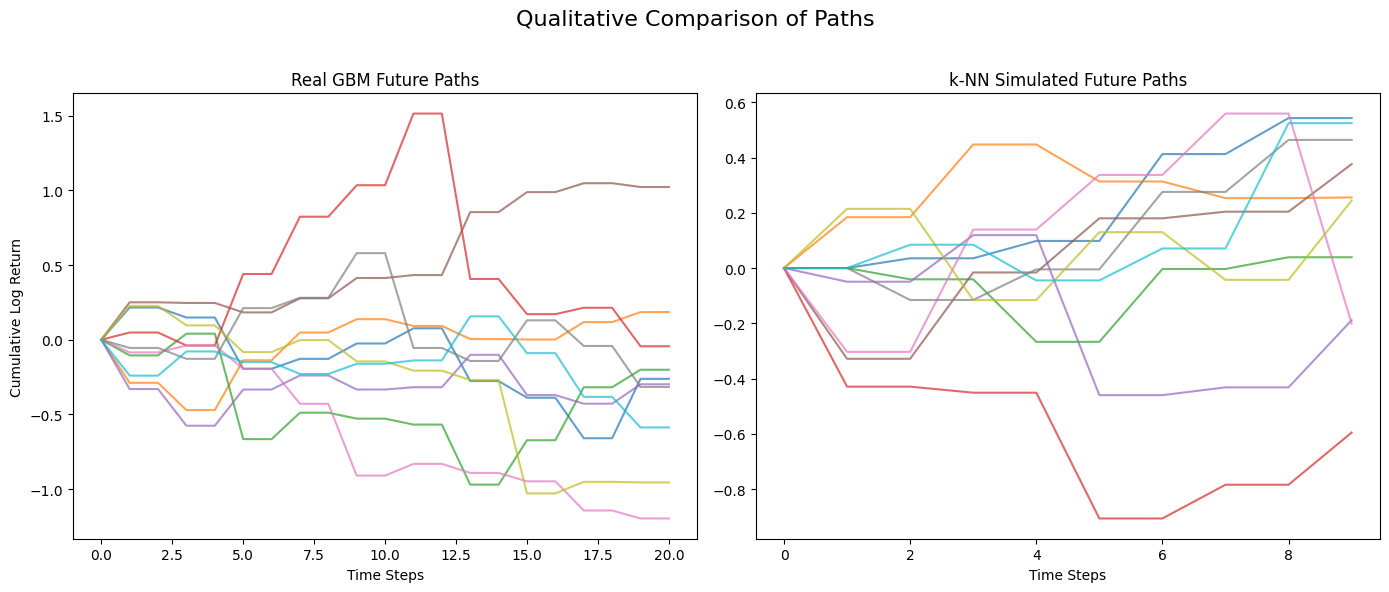

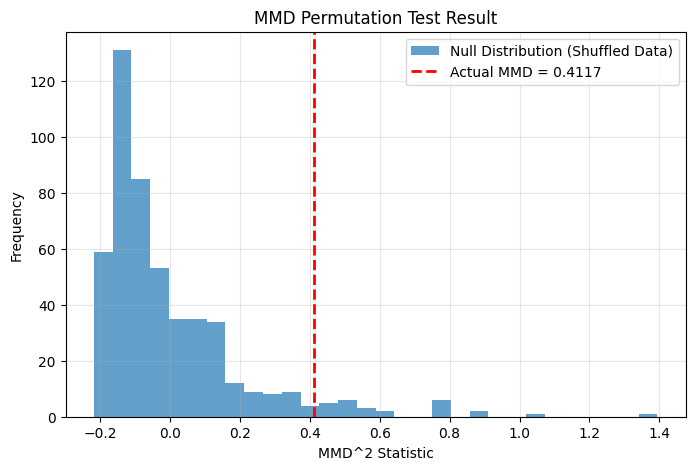

In [32]:
if __name__ == '__main__':
    # --- Model & Simulation Parameters ---
    # CEV Parameters (replace GBM)
    mu = 0.05
    sigma = 0.5  # Increased sigma slightly for more interesting paths
    gamma = 1.2  # Key CEV parameter < 1 for leverage effect
    S0 = 100

    # Path and Model Hyperparameters (can remain the same)
    n_steps_lookback = 10
    n_steps_forecast = 10 # Let's use a consistent 10 for both

    SIGNATURE_LEVEL = 4
    K_NEIGHBORS = 20

    # --- Data Generation ---
    print("Step 1: Generating 'Real' Data from CEV model...")
    n_library_paths = 500
    n_test_paths = 20
    # Make sure total steps accommodate the new forecast length
    total_steps_needed = n_steps_lookback + n_steps_forecast

    # *** THE ONLY MAJOR CHANGE IS THIS LINE ***
    library_real_paths = generate_cev_paths(n_library_paths, total_steps_needed, mu, sigma, gamma, S0)
    test_real_paths = generate_cev_paths(n_test_paths, total_steps_needed, mu, sigma, gamma, S0)

    # --- The Rest of The Script Remains Unchanged ---
    # The framework is agnostic to the data source.

    print("\nStep 2: Building the Signature Library...")
    # NOTE: You will need the corrected `create_path_library` from our last discussion.
    processed_library_paths = preprocess_paths(library_real_paths)
    path_library = create_path_library(processed_library_paths, n_steps_lookback, n_steps_forecast, SIGNATURE_LEVEL)

    # --- Simulation ---
    print("\nStep 3: Simulating New Paths with k-NN Generator...")
    start_paths_for_sim = test_real_paths[:, :n_steps_lookback + 1]
    simulated_paths = generate_new_paths(start_paths_for_sim, path_library, K_NEIGHBORS, SIGNATURE_LEVEL)

    # The "true" futures that correspond to our starting paths
    real_future_paths = preprocess_paths(test_real_paths[:, n_steps_lookback:])

  # --- Validation with MMD Test ---
    print("\nStep 4: Checking if Distributions Match using MMD Test...")
    mmd_value, p_value, null_distribution = permutation_test(
        real_future_paths,
        simulated_paths,
        SIGNATURE_LEVEL
    )

    print(f"\n--- Test Results ---")
    print(f"MMD^2 Statistic: {mmd_value:.6f}")
    print(f"P-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusion: We FAIL to reject the null hypothesis.")
        print("The distribution of simulated paths is statistically SIMILAR to the real CEV paths.")
    else:
        print("Conclusion: We REJECT the null hypothesis.")
        print("The distribution of simulated paths is statistically DIFFERENT from the real CEV paths.")

    # --- Visualization ---
    # 1. Plot some example paths
    plt.figure(figsize=(14, 6))
    plt.suptitle('Qualitative Comparison of Paths', fontsize=16)

    ax1 = plt.subplot(1, 2, 1)
    for i in range(10):
        # To plot, we need to convert back to a 1D cumulative return path
        path_1d = real_future_paths[i][:, 0]
        ax1.plot(path_1d, alpha=0.7)
    ax1.set_title('Real GBM Future Paths')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Cumulative Log Return')

    ax2 = plt.subplot(1, 2, 2)
    for i in range(10):
        path_1d = simulated_paths[i][:, 0]
        ax2.plot(path_1d, alpha=0.7)
    ax2.set_title('k-NN Simulated Future Paths')
    ax2.set_xlabel('Time Steps')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # 2. Plot the MMD test result
    plt.figure(figsize=(8, 5))
    plt.hist(null_distribution, bins=30, alpha=0.7, label='Null Distribution (Shuffled Data)')
    plt.axvline(mmd_value, color='red', linestyle='--', linewidth=2, label=f'Actual MMD = {mmd_value:.4f}')
    plt.title('MMD Permutation Test Result')
    plt.xlabel('MMD^2 Statistic')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Step 1: Generating 'Real' Data from Geometric Mean-Reverting model...

Step 2: Building the Signature Library...


Building Library: 100%|██████████| 300/300 [00:00<00:00, 1761.02it/s]



Step 3: Simulating New Paths with k-NN Generator...


Generating Paths: 100%|██████████| 100/100 [00:04<00:00, 22.06it/s]



Step 4: Checking if Distributions Match using MMD Test...


Running Permutation Test: 100%|██████████| 500/500 [00:01<00:00, 308.90it/s]



--- Test Results ---
MMD^2 Statistic: -0.000198
P-value: 0.5780
Conclusion: We FAIL to reject the null hypothesis.
The distribution of simulated paths is statistically SIMILAR to the real GMR paths.


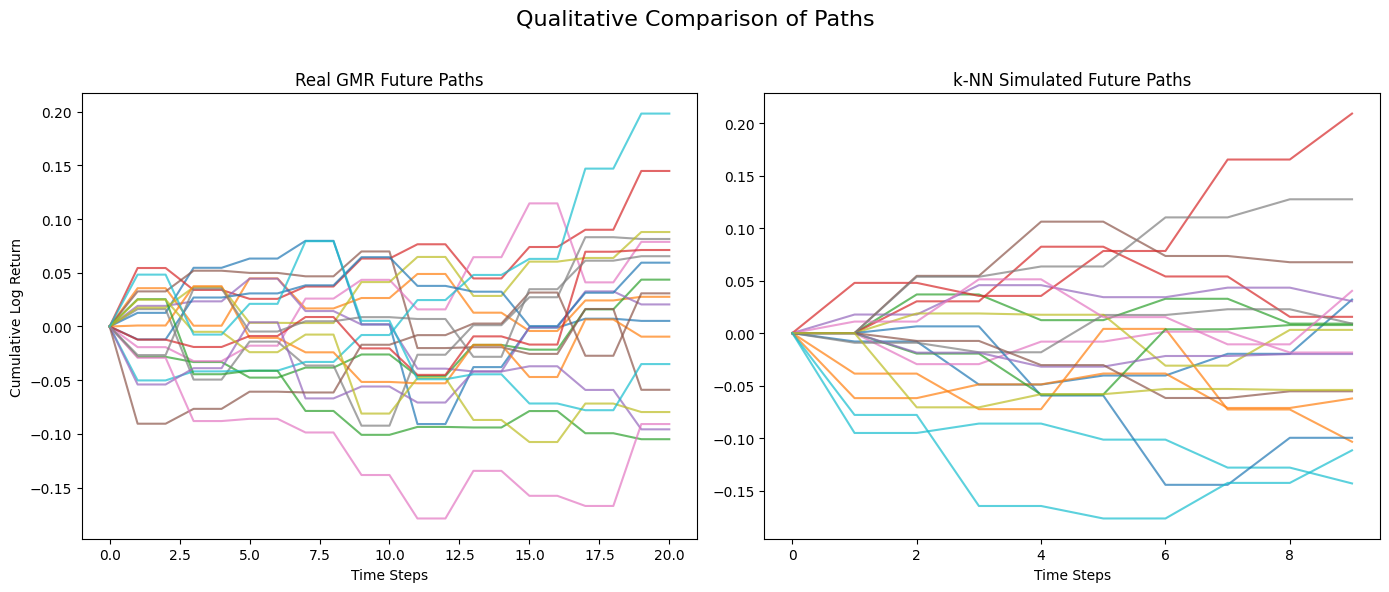

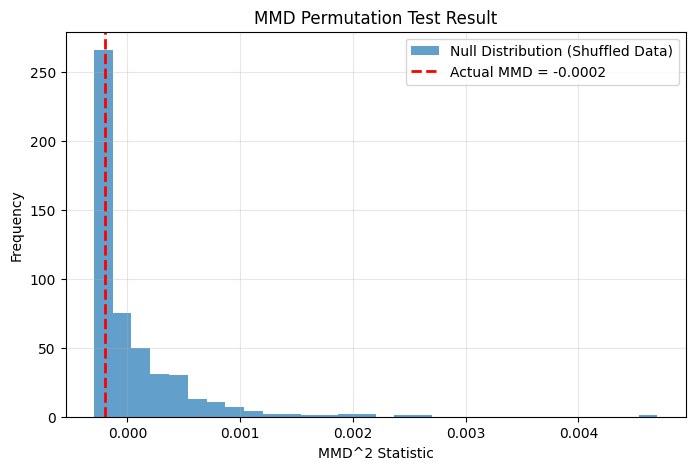

In [42]:
if __name__ == '__main__':
    # --- Model & Simulation Parameters ---
    # Geometric Mean-Reverting Parameters (replace CEV)
    kappa = 3.0     # Speed of reversion
    theta = np.log(100) # Log of the mean price level
    sigma = 0.2     # Volatility
    S0 = 110

    # Path and Model Hyperparameters (can remain the same)
    n_steps_lookback = 20
    n_steps_forecast = 10

    SIGNATURE_LEVEL = 4
    K_NEIGHBORS = 20

    # --- Data Generation ---
    print("Step 1: Generating 'Real' Data from Geometric Mean-Reverting model...")
    n_library_paths = 300
    n_test_paths = 100
    total_steps_needed = n_steps_lookback + n_steps_forecast

    # *** THE ONLY MAJOR CHANGE IS THIS LINE ***
    library_real_paths = generate_gmr_paths(n_library_paths, total_steps_needed, kappa, theta, sigma, S0)
    test_real_paths = generate_gmr_paths(n_test_paths, total_steps_needed, kappa, theta, sigma, S0)

    # --- The Rest of The Script Remains Unchanged ---
    # The framework learns the new dynamics automatically.

    print("\nStep 2: Building the Signature Library...")
    processed_library_paths = preprocess_paths(library_real_paths)
    path_library = create_path_library(processed_library_paths, n_steps_lookback, n_steps_forecast, SIGNATURE_LEVEL)

    # --- Simulation ---
    print("\nStep 3: Simulating New Paths with k-NN Generator...")
    start_paths_for_sim = test_real_paths[:, :n_steps_lookback + 1]
    simulated_paths = generate_new_paths(start_paths_for_sim, path_library, K_NEIGHBORS, SIGNATURE_LEVEL)

    # The "true" futures that correspond to our starting paths
    real_future_paths = preprocess_paths(test_real_paths[:, n_steps_lookback:])


  # --- Validation with MMD Test ---
    print("\nStep 4: Checking if Distributions Match using MMD Test...")
    mmd_value, p_value, null_distribution = permutation_test(
        real_future_paths,
        simulated_paths,
        SIGNATURE_LEVEL
    )

    print(f"\n--- Test Results ---")
    print(f"MMD^2 Statistic: {mmd_value:.6f}")
    print(f"P-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusion: We FAIL to reject the null hypothesis.")
        print("The distribution of simulated paths is statistically SIMILAR to the real GMR paths.")
    else:
        print("Conclusion: We REJECT the null hypothesis.")
        print("The distribution of simulated paths is statistically DIFFERENT from the real GMR paths.")

    # --- Visualization ---
    # 1. Plot some example paths
    plt.figure(figsize=(14, 6))
    plt.suptitle('Qualitative Comparison of Paths', fontsize=16)

    ax1 = plt.subplot(1, 2, 1)
    for i in range(20):
        # To plot, we need to convert back to a 1D cumulative return path
        path_1d = real_future_paths[i][:, 0]
        ax1.plot(path_1d, alpha=0.7)
    ax1.set_title('Real GMR Future Paths')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Cumulative Log Return')

    ax2 = plt.subplot(1, 2, 2)
    for i in range(20):
        path_1d = simulated_paths[i][:, 0]
        ax2.plot(path_1d, alpha=0.7)
    ax2.set_title('k-NN Simulated Future Paths')
    ax2.set_xlabel('Time Steps')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # 2. Plot the MMD test result
    plt.figure(figsize=(8, 5))
    plt.hist(null_distribution, bins=30, alpha=0.7, label='Null Distribution (Shuffled Data)')
    plt.axvline(mmd_value, color='red', linestyle='--', linewidth=2, label=f'Actual MMD = {mmd_value:.4f}')
    plt.title('MMD Permutation Test Result')
    plt.xlabel('MMD^2 Statistic')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Loading data from audusd2-1m.csv...
Loaded 100000 data points.

Step 1: Building Signature Library from Training Data...


Building Library: 100%|██████████| 79966/79966 [00:12<00:00, 6254.37it/s]



Step 2: Generating Scenarios from Recent Data...

Step 3: Validating Distributions with MMD Test...


Running Permutation Test: 100%|██████████| 200/200 [00:01<00:00, 181.16it/s]



--- MMD Test Results ---
MMD^2 Statistic: 0.000000
P-value: 0.0500
Conclusion: We REJECT the null hypothesis (distributions are different).

Step 4: Plotting Results...


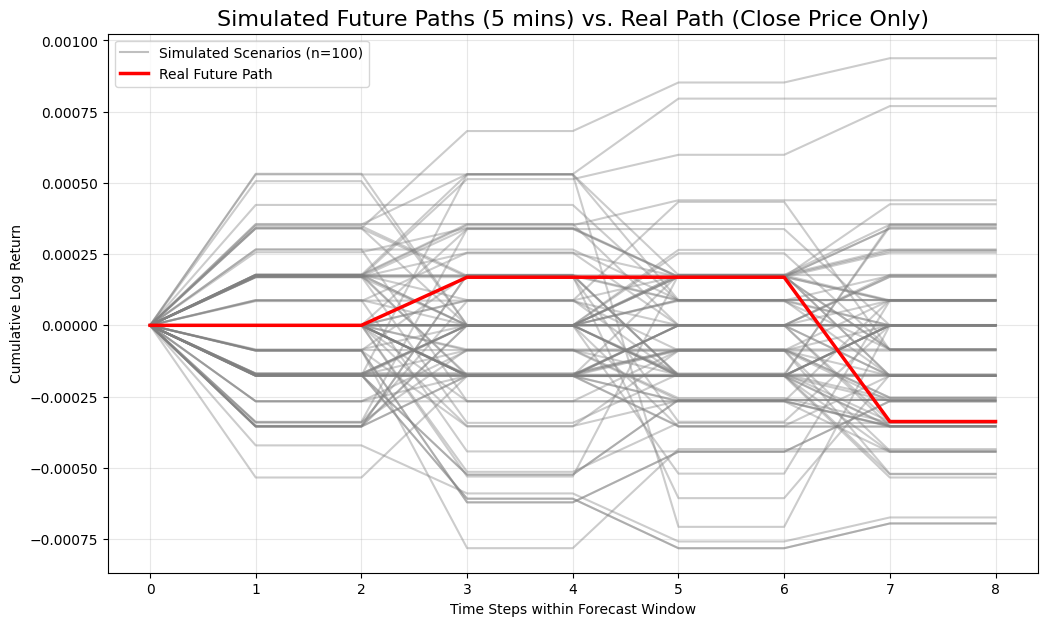

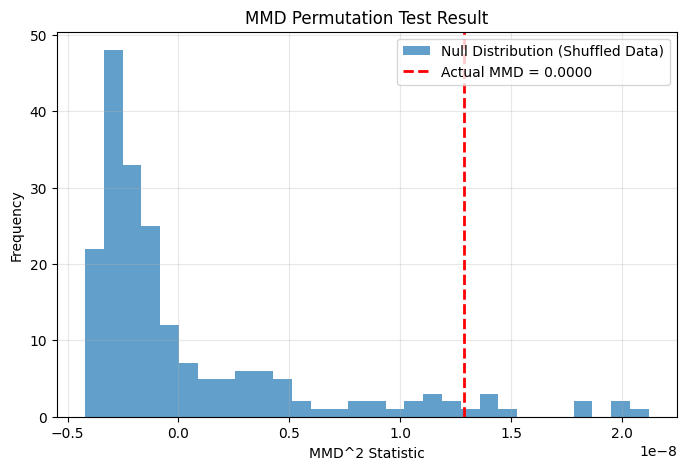

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iisignature
from tqdm import tqdm
import sys # Import sys to use sys.exit for a more robust exit

# --- Part 1: Data Loading and Simplified Preprocessing ---

def load_real_data(filepath, nrows=None):
    """
    Loads and parses the specific semicolon-delimited OHLC data format.
    Returns just the 'Close' price series.
    """
    print(f"Loading data from {filepath}...")
    # Define column names based on the file format
    col_names = ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume']

    # Load the data without parsing dates initially
    df = pd.read_csv(
        filepath,
        sep=';',
        header=None,
        names=col_names,
        nrows=nrows
    )

    # Combine 'Date' and 'Time' columns and convert to datetime objects
    df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    df.set_index('Timestamp', inplace=True)
    df.drop(['Date', 'Time'], axis=1, inplace=True) # Drop the original string columns

    # We don't need volume for a close-price-only model.
    # df = df[df['Volume'] > 0]

    print(f"Loaded {len(df)} data points.")
    if len(df) == 0:
        print("Warning: Data file loaded but is empty. Exiting.")
        sys.exit()

    return df['Close']


def preprocess_close_price_series(close_prices: np.ndarray):
    """
    Converts a 1D series of close prices into a lead-lag path of cumulative log returns.
    """
    if np.any(close_prices <= 0):
        return None

    log_returns = np.log(close_prices[1:] / close_prices[:-1])
    cumulative_log_returns = np.insert(np.cumsum(log_returns), 0, 0)

    repeated = np.repeat(cumulative_log_returns, 2)
    lead = repeated[1:]
    lag = repeated[:-1]

    # Re-base the path to start at 0
    relative_path = np.stack([lead, lag], axis=1)
    return relative_path - relative_path[0]


# --- Part 2: Library Creation and Generative Model ---

def create_path_library(close_price_series: np.ndarray, n_lookback: int, m_forecast: int, sig_level: int):
    """
    Creates the library from a 1D time series of close prices.
    """
    library = []
    total_window = n_lookback + m_forecast

    for i in tqdm(range(len(close_price_series) - total_window + 1), desc="Building Library"):

        past_prices = close_price_series[i : i + n_lookback]
        future_prices = close_price_series[i : i + m_forecast]

        past_log_return_path = preprocess_close_price_series(past_prices)
        future_log_return_path = preprocess_close_price_series(future_prices)

        if past_log_return_path is None or future_log_return_path is None:
            continue

        past_signature = iisignature.sig(past_log_return_path, sig_level)

        # We store the already relative future path
        library.append({'signature': past_signature, 'future': future_log_return_path})

    return library


def generate_new_paths(start_close_prices: np.ndarray, library: list, k: int, n_sims: int, sig_level: int):
    """
    Generates new paths by sampling from the k-nearest neighbors.
    """
    start_log_return_path = preprocess_close_price_series(start_close_prices)

    if start_log_return_path is None:
        raise ValueError("Starting path data is invalid.")

    current_sig = iisignature.sig(start_log_return_path, sig_level)

    # Find the pool of k-nearest neighbors
    distances = [np.linalg.norm(current_sig - item['signature']) for item in library]
    knn_indices = np.argsort(distances)[:k]

    # Randomly sample from the pool of neighbors
    simulated_indices = np.random.choice(knn_indices, size=n_sims, replace=True)

    # The generated paths are the futures of the randomly sampled neighbors
    simulated_futures = [library[i]['future'] for i in simulated_indices]

    return simulated_futures

# --- Part 3: MMD Two-Sample Test ---

def calculate_mmd(paths_A, paths_B, sig_level):
    """
    Calculates the Maximum Mean Discrepancy (MMD) statistic between two
    sets of paths using the signature kernel.
    """
    # Pre-compute all signatures for efficiency
    sigs_A = [iisignature.sig(p, sig_level) for p in paths_A]
    sigs_B = [iisignature.sig(p, sig_level) for p in paths_B]

    n = len(sigs_A)
    m = len(sigs_B)

    if n < 2 or m < 2:
        return 0 # Cannot compute MMD for sets smaller than 2

    # Calculate Gram matrices (containing all pairwise dot products)
    gram_AA = np.dot(np.array(sigs_A), np.array(sigs_A).T)
    gram_BB = np.dot(np.array(sigs_B), np.array(sigs_B).T)
    gram_AB = np.dot(np.array(sigs_A), np.array(sigs_B).T)

    # Calculate the three terms of the MMD^2 formula (unbiased estimator)
    term_A = (np.sum(gram_AA) - np.trace(gram_AA)) / (n * (n - 1))
    term_B = (np.sum(gram_BB) - np.trace(gram_BB)) / (m * (m - 1))
    term_AB = np.mean(gram_AB)

    return term_A + term_B - 2 * term_AB

def permutation_test(paths_A, paths_B, sig_level, n_permutations=200):
    """
    Performs a permutation test to assess the significance of the MMD.
    """
    # Calculate the MMD for the original samples
    real_mmd = calculate_mmd(paths_A, paths_B, sig_level)

    # Pool all paths together
    all_paths = paths_A + paths_B
    n_A = len(paths_A)

    permuted_mmds = []
    for _ in tqdm(range(n_permutations), desc="Running Permutation Test"):
        # Shuffle the pooled paths
        np.random.shuffle(all_paths)
        # Create new fake sets
        perm_A = all_paths[:n_A]
        perm_B = all_paths[n_A:]
        # Calculate MMD for the permuted sets
        permuted_mmds.append(calculate_mmd(perm_A, perm_B, sig_level))

    # The p-value is the proportion of permuted MMDs that are >= the real MMD
    p_value = np.mean(np.array(permuted_mmds) >= real_mmd)

    return real_mmd, p_value, permuted_mmds


# --- Part 4: Main Execution and Visualization ---

if __name__ == '__main__':
    # --- Parameters ---
    FILEPATH = 'audusd2-1m.csv'
    N_ROWS_TO_LOAD = 100000

    # Window sizes (in minutes)
    N_LOOKBACK = 30  # 2 hours
    M_FORECAST = 5   # 30 minutes

    # Model Hyperparameters
    SIGNATURE_LEVEL = 5
    K_NEIGHBORS_POOL = 2000   # Find the 50 most similar pasts...
    N_SIMULATIONS = 100      # ...and generate 20 scenarios from that pool.

    # --- Data Loading and Splitting ---
    try:
        close_price_df = load_real_data(FILEPATH, nrows=N_ROWS_TO_LOAD)

        close_price_series = close_price_df.values

        # Split data into a "training" set for the library and a "testing" set for simulation
        split_index = int(len(close_price_series) * 0.8)
        train_series = close_price_series[:split_index]
        test_series = close_price_series[split_index:]

        # --- Library Creation ---
        print("\nStep 1: Building Signature Library from Training Data...")
        path_library = create_path_library(train_series, N_LOOKBACK, M_FORECAST, SIGNATURE_LEVEL)

        if not path_library:
            print("\nERROR: Library could not be built. Check data quality or window sizes.")
            sys.exit()

        # --- Simulation ---
        print("\nStep 2: Generating Scenarios from Recent Data...")
        # We'll use a random starting point from the test set for simulation
        rand_start_index = np.random.randint(0, len(test_series) - N_LOOKBACK)
        start_prices = test_series[rand_start_index : rand_start_index + N_LOOKBACK]

        simulated_paths = generate_new_paths(start_prices, path_library, K_NEIGHBORS_POOL, N_SIMULATIONS, SIGNATURE_LEVEL)

        # --- MMD Test Validation ---
        print("\nStep 3: Validating Distributions with MMD Test...")
        # Create a representative set of real future paths from the test data
        real_futures_set = []
        for i in range(N_SIMULATIONS * 2): # Create a slightly larger set for a robust test
            rand_idx = np.random.randint(0, len(test_series) - M_FORECAST)
            real_prices = test_series[rand_idx : rand_idx + M_FORECAST]
            real_path = preprocess_close_price_series(real_prices)
            if real_path is not None:
                real_futures_set.append(real_path)

        if len(real_futures_set) > 1 and len(simulated_paths) > 1:
            mmd_value, p_value, null_distribution = permutation_test(
                real_futures_set,
                simulated_paths,
                SIGNATURE_LEVEL
            )
            print(f"\n--- MMD Test Results ---")
            print(f"MMD^2 Statistic: {mmd_value:.6f}")
            print(f"P-value: {p_value:.4f}")
            if p_value > 0.05:
                print("Conclusion: We FAIL to reject the null hypothesis (distributions are similar).")
            else:
                print("Conclusion: We REJECT the null hypothesis (distributions are different).")
        else:
            print("Could not run MMD test: Not enough valid paths.")


        # --- Visualization ---
        print("\nStep 4: Plotting Results...")

        # We need the single "real future" that corresponds to our simulation's start point
        real_future_prices = test_series[rand_start_index + N_LOOKBACK : rand_start_index + N_LOOKBACK + M_FORECAST]
        real_future_relative = preprocess_close_price_series(real_future_prices)

        # Plot the simulation fan chart
        plt.figure(figsize=(12, 7))
        plt.title(f'Simulated Future Paths ({M_FORECAST} mins) vs. Real Path (Close Price Only)', fontsize=16)

        for i, sim_path in enumerate(simulated_paths):
            plt.plot(sim_path[:, 0], color='gray', alpha=0.4, label='_nolegend_')

        plt.plot([], [], color='gray', alpha=0.5, label=f'Simulated Scenarios (n={N_SIMULATIONS})')

        if real_future_relative is not None:
            plt.plot(real_future_relative[:, 0], color='red', linewidth=2.5, label='Real Future Path')

        plt.ylabel('Cumulative Log Return')
        plt.xlabel('Time Steps within Forecast Window')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        # Plot the MMD test result if available
        if 'null_distribution' in locals():
            plt.figure(figsize=(8, 5))
            plt.hist(null_distribution, bins=30, alpha=0.7, label='Null Distribution (Shuffled Data)')
            plt.axvline(mmd_value, color='red', linestyle='--', linewidth=2, label=f'Actual MMD = {mmd_value:.4f}')
            plt.title('MMD Permutation Test Result')
            plt.xlabel('MMD^2 Statistic')
            plt.ylabel('Frequency')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()


    except FileNotFoundError:
        print(f"ERROR: Data file not found at '{FILEPATH}'")
        print("Please place your data file in the same directory or provide the full path.")
        sys.exit()
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        sys.exit()



Step 2: Generating Scenarios from Recent Data...

Step 3: Validating Distributions with MMD Test...


Running Permutation Test: 100%|██████████| 200/200 [00:01<00:00, 188.07it/s]



--- MMD Test Results ---
MMD^2 Statistic: -0.000000
P-value: 0.3900
Conclusion: We FAIL to reject the null hypothesis (distributions are similar).

Step 4: Plotting Results...


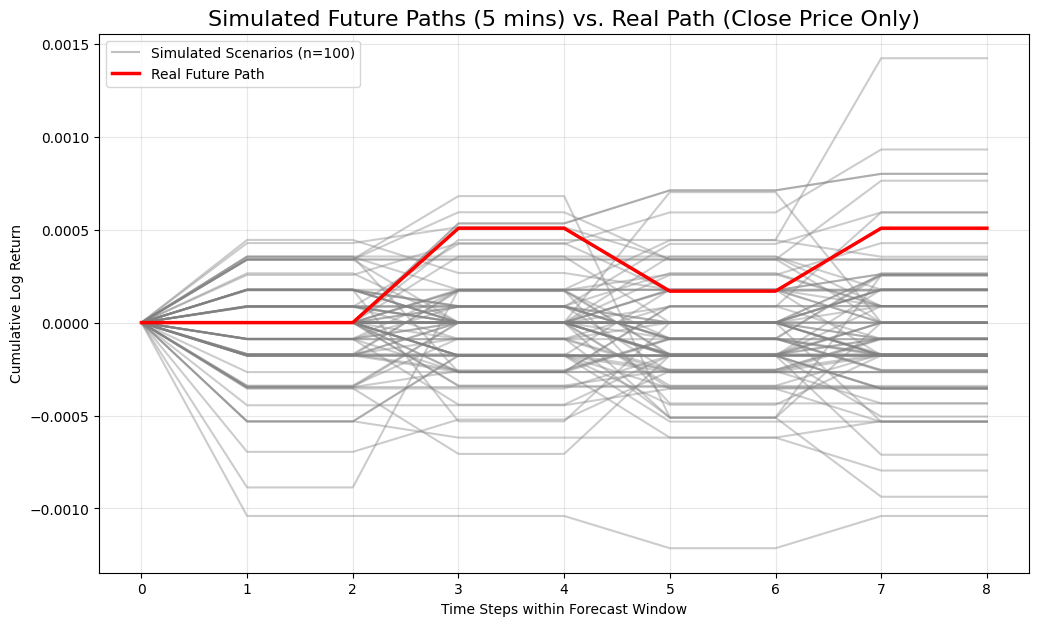

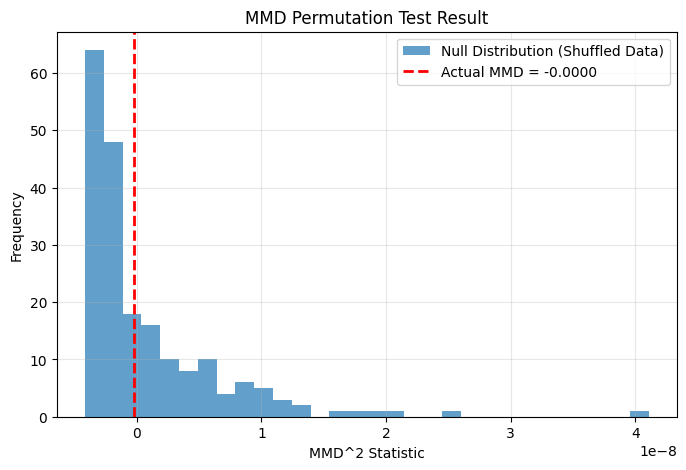

In [117]:
# --- Simulation ---
print("\nStep 2: Generating Scenarios from Recent Data...")
# We'll use a random starting point from the test set for simulation
rand_start_index = np.random.randint(0, len(test_series) - N_LOOKBACK)
start_prices = test_series[rand_start_index : rand_start_index + N_LOOKBACK]

simulated_paths = generate_new_paths(start_prices, path_library, K_NEIGHBORS_POOL, N_SIMULATIONS, SIGNATURE_LEVEL)

# --- MMD Test Validation ---
print("\nStep 3: Validating Distributions with MMD Test...")
# Create a representative set of real future paths from the test data
real_futures_set = []
for i in range(N_SIMULATIONS * 2): # Create a slightly larger set for a robust test
    rand_idx = np.random.randint(0, len(test_series) - M_FORECAST)
    real_prices = test_series[rand_idx : rand_idx + M_FORECAST]
    real_path = preprocess_close_price_series(real_prices)
    if real_path is not None:
        real_futures_set.append(real_path)

if len(real_futures_set) > 1 and len(simulated_paths) > 1:
    mmd_value, p_value, null_distribution = permutation_test(
        real_futures_set,
        simulated_paths,
        SIGNATURE_LEVEL
    )
    print(f"\n--- MMD Test Results ---")
    print(f"MMD^2 Statistic: {mmd_value:.6f}")
    print(f"P-value: {p_value:.4f}")
    if p_value > 0.05:
        print("Conclusion: We FAIL to reject the null hypothesis (distributions are similar).")
    else:
        print("Conclusion: We REJECT the null hypothesis (distributions are different).")
else:
    print("Could not run MMD test: Not enough valid paths.")


# --- Visualization ---
print("\nStep 4: Plotting Results...")

# We need the single "real future" that corresponds to our simulation's start point
real_future_prices = test_series[rand_start_index + N_LOOKBACK : rand_start_index + N_LOOKBACK + M_FORECAST]
real_future_relative = preprocess_close_price_series(real_future_prices)

# Plot the simulation fan chart
plt.figure(figsize=(12, 7))
plt.title(f'Simulated Future Paths ({M_FORECAST} mins) vs. Real Path (Close Price Only)', fontsize=16)

for i, sim_path in enumerate(simulated_paths):
    plt.plot(sim_path[:, 0], color='gray', alpha=0.4, label='_nolegend_')

plt.plot([], [], color='gray', alpha=0.5, label=f'Simulated Scenarios (n={N_SIMULATIONS})')

if real_future_relative is not None:
    plt.plot(real_future_relative[:, 0], color='red', linewidth=2.5, label='Real Future Path')

plt.ylabel('Cumulative Log Return')
plt.xlabel('Time Steps within Forecast Window')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot the MMD test result if available
if 'null_distribution' in locals():
    plt.figure(figsize=(8, 5))
    plt.hist(null_distribution, bins=30, alpha=0.7, label='Null Distribution (Shuffled Data)')
    plt.axvline(mmd_value, color='red', linestyle='--', linewidth=2, label=f'Actual MMD = {mmd_value:.4f}')
    plt.title('MMD Permutation Test Result')
    plt.xlabel('MMD^2 Statistic')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Loading data from audusd2-1m.csv...
Loaded 20000 data points.

Step 1: Building Signature Library from Training Data...


Building Library: 100%|██████████| 15936/15936 [00:02<00:00, 6096.73it/s]



Step 3: Running Percentile Rank Test (200 iterations)...


Running Rank Test: 100%|██████████| 200/200 [00:16<00:00, 11.95it/s]



--- Percentile Rank Test Results ---
Kolmogorov-Smirnov Test Statistic: 0.0650
P-value: 0.3516
Conclusion: We FAIL to reject the null hypothesis (ranks are uniformly distributed).
This indicates the model is well-calibrated.

Step 4: Plotting a Single Example Scenario...


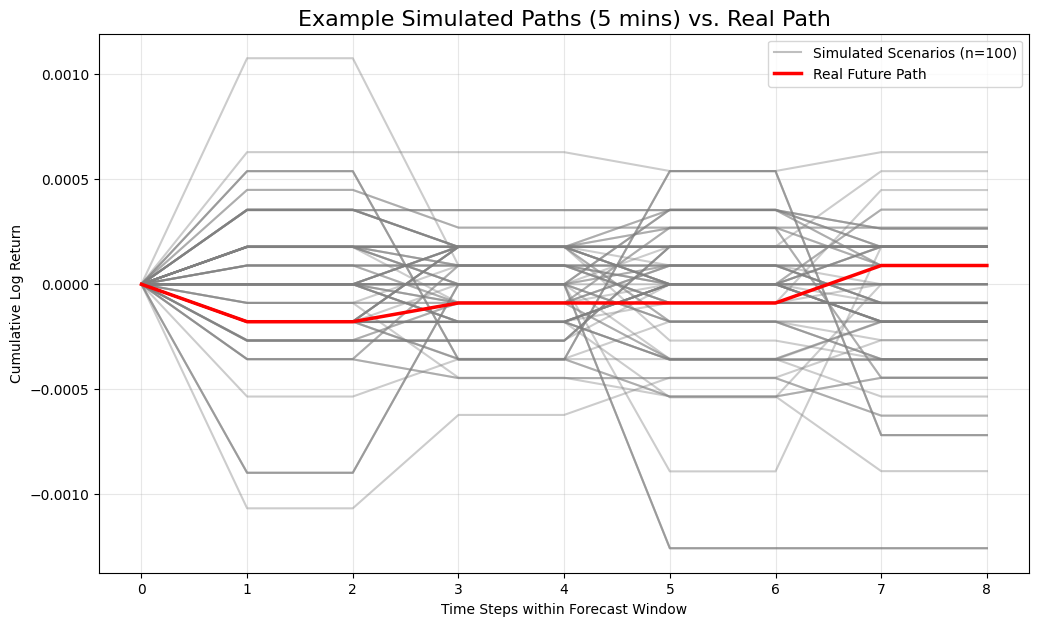

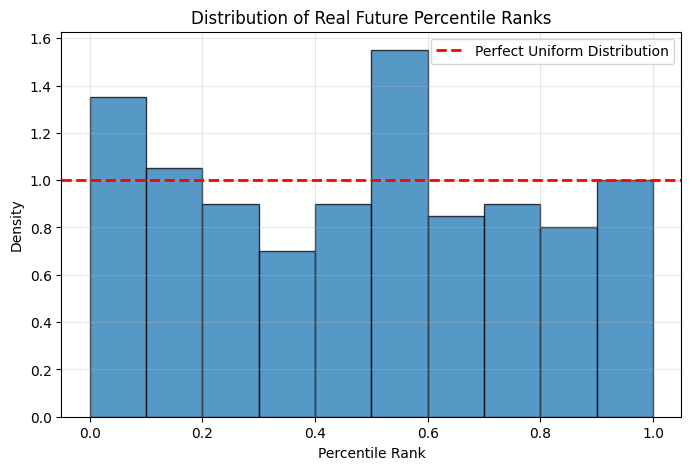

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iisignature
from tqdm import tqdm
import sys
from scipy import stats # Import for the Kolmogorov-Smirnov test

# --- Part 1: Data Loading and Simplified Preprocessing ---

def load_real_data(filepath, nrows=None):
    """
    Loads and parses the specific semicolon-delimited OHLC data format.
    Returns just the 'Close' price series.
    """
    print(f"Loading data from {filepath}...")
    col_names = ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume']

    df = pd.read_csv(
        filepath,
        sep=';',
        header=None,
        names=col_names,
        nrows=nrows
    )

    df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    df.set_index('Timestamp', inplace=True)
    df.drop(['Date', 'Time'], axis=1, inplace=True)

    print(f"Loaded {len(df)} data points.")
    if len(df) == 0:
        print("Warning: Data file loaded but is empty. Exiting.")
        sys.exit()

    return df['Close']


def preprocess_close_price_series(close_prices: np.ndarray):
    """
    Converts a 1D series of close prices into a lead-lag path of cumulative log returns.
    """
    if np.any(close_prices <= 0):
        return None

    log_returns = np.log(close_prices[1:] / close_prices[:-1])
    cumulative_log_returns = np.insert(np.cumsum(log_returns), 0, 0)

    repeated = np.repeat(cumulative_log_returns, 2)
    lead = repeated[1:]
    lag = repeated[:-1]

    relative_path = np.stack([lead, lag], axis=1)
    return relative_path - relative_path[0]


# --- Part 2: Library Creation and Generative Model ---

def create_path_library(close_price_series: np.ndarray, n_lookback: int, m_forecast: int, sig_level: int):
    """
    Creates the library from a 1D time series of close prices.
    """
    library = []
    total_window = n_lookback + m_forecast

    for i in tqdm(range(len(close_price_series) - total_window + 1), desc="Building Library"):

        past_prices = close_price_series[i : i + n_lookback]
        future_prices = close_price_series[i : i + m_forecast]

        past_log_return_path = preprocess_close_price_series(past_prices)
        future_log_return_path = preprocess_close_price_series(future_prices)

        if past_log_return_path is None or future_log_return_path is None:
            continue

        past_signature = iisignature.sig(past_log_return_path, sig_level)

        library.append({'signature': past_signature, 'future': future_log_return_path})

    return library


def generate_new_paths(start_close_prices: np.ndarray, library: list, k: int, n_sims: int, sig_level: int):
    """
    Generates new paths by sampling from the k-nearest neighbors.
    """
    start_log_return_path = preprocess_close_price_series(start_close_prices)

    if start_log_return_path is None:
        raise ValueError("Starting path data is invalid.")

    current_sig = iisignature.sig(start_log_return_path, sig_level)

    distances = [np.linalg.norm(current_sig - item['signature']) for item in library]
    knn_indices = np.argsort(distances)[:k]

    simulated_indices = np.random.choice(knn_indices, size=n_sims, replace=True)

    simulated_futures = [library[i]['future'] for i in simulated_indices]

    return simulated_futures

# --- Part 3: Percentile Rank Validation Test ---

def run_percentile_rank_test(test_series, library, n_lookback, m_forecast, k_pool, n_sims, sig_level, n_test_runs=200):
    """
    Runs multiple simulations to get the distribution of percentile ranks.
    """
    print(f"\nStep 3: Running Percentile Rank Test ({n_test_runs} iterations)...")
    percentile_ranks = []

    for _ in tqdm(range(n_test_runs), desc="Running Rank Test"):
        # Pick a random starting point in the test set
        rand_start_index = np.random.randint(0, len(test_series) - (n_lookback + m_forecast))

        # Define the past and future windows for this run
        start_prices = test_series[rand_start_index : rand_start_index + n_lookback]
        real_future_prices = test_series[rand_start_index + n_lookback : rand_start_index + n_lookback + m_forecast]

        # Generate simulations for this specific past
        simulated_paths = generate_new_paths(start_prices, library, k_pool, n_sims, sig_level)

        # Preprocess the real future to get its terminal value
        real_future_relative = preprocess_close_price_series(real_future_prices)
        if real_future_relative is None:
            continue

        # Terminal value is the final cumulative log return
        real_terminal_value = real_future_relative[-1, 0]

        # Get terminal values for all simulations
        simulated_terminal_values = [path[-1, 0] for path in simulated_paths]

        # Calculate the percentile rank of the real outcome
        # This is the proportion of simulations that were less than or equal to the real outcome
        rank = stats.percentileofscore(simulated_terminal_values, real_terminal_value, kind='weak') / 100.0
        percentile_ranks.append(rank)

    return np.array(percentile_ranks)


# --- Part 4: Main Execution and Visualization ---

if __name__ == '__main__':
    # --- Parameters ---
    FILEPATH = 'audusd2-1m.csv'
    N_ROWS_TO_LOAD = 20000

    # Window sizes (in minutes)
    N_LOOKBACK = 60  # A shorter window, as we found it works better
    M_FORECAST = 5

    # Model Hyperparameters
    SIGNATURE_LEVEL = 3
    K_NEIGHBORS_POOL = 75
    N_SIMULATIONS = 100

    # --- Data Loading and Splitting ---
    try:
        close_price_df = load_real_data(FILEPATH, nrows=N_ROWS_TO_LOAD)

        close_price_series = close_price_df.values

        # Split data into a "training" set for the library and a "testing" set for simulation
        split_index = int(len(close_price_series) * 0.8)
        train_series = close_price_series[:split_index]
        test_series = close_price_series[split_index:]

        # --- Library Creation ---
        print("\nStep 1: Building Signature Library from Training Data...")
        path_library = create_path_library(train_series, N_LOOKBACK, M_FORECAST, SIGNATURE_LEVEL)

        if not path_library:
            print("\nERROR: Library could not be built. Check data quality or window sizes.")
            sys.exit()

        # --- Percentile Rank Test ---
        percentile_ranks = run_percentile_rank_test(
            test_series, path_library, N_LOOKBACK, M_FORECAST,
            K_NEIGHBORS_POOL, N_SIMULATIONS, SIGNATURE_LEVEL
        )

        # --- Statistical Test for Uniformity ---
        if len(percentile_ranks) > 0:
            ks_stat, p_value = stats.kstest(percentile_ranks, 'uniform')
            print(f"\n--- Percentile Rank Test Results ---")
            print(f"Kolmogorov-Smirnov Test Statistic: {ks_stat:.4f}")
            print(f"P-value: {p_value:.4f}")
            if p_value > 0.05:
                print("Conclusion: We FAIL to reject the null hypothesis (ranks are uniformly distributed).")
                print("This indicates the model is well-calibrated.")
            else:
                print("Conclusion: We REJECT the null hypothesis (ranks are NOT uniformly distributed).")
                print("This indicates the model may have a bias.")

        # --- Single Instance Visualization ---
        print("\nStep 4: Plotting a Single Example Scenario...")
        start_prices = test_series[-(N_LOOKBACK + M_FORECAST) : -M_FORECAST]
        real_future_prices = test_series[-M_FORECAST:]

        simulated_paths = generate_new_paths(start_prices, path_library, K_NEIGHBORS_POOL, N_SIMULATIONS, SIGNATURE_LEVEL)

        real_future_relative = preprocess_close_price_series(real_future_prices)

        # Plot the simulation fan chart
        plt.figure(figsize=(12, 7))
        plt.title(f'Example Simulated Paths ({M_FORECAST} mins) vs. Real Path', fontsize=16)

        for i, sim_path in enumerate(simulated_paths):
            plt.plot(sim_path[:, 0], color='gray', alpha=0.4, label='_nolegend_')

        plt.plot([], [], color='gray', alpha=0.5, label=f'Simulated Scenarios (n={N_SIMULATIONS})')

        if real_future_relative is not None:
            plt.plot(real_future_relative[:, 0], color='red', linewidth=2.5, label='Real Future Path')

        plt.ylabel('Cumulative Log Return')
        plt.xlabel('Time Steps within Forecast Window')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        # Plot the percentile rank distribution if available
        if len(percentile_ranks) > 0:
            plt.figure(figsize=(8, 5))
            plt.hist(percentile_ranks, bins=np.linspace(0, 1, 11), density=True, alpha=0.75, edgecolor='black')
            plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Perfect Uniform Distribution')
            plt.title('Distribution of Real Future Percentile Ranks')
            plt.xlabel('Percentile Rank')
            plt.ylabel('Density')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

    except FileNotFoundError:
        print(f"ERROR: Data file not found at '{FILEPATH}'")
        print("Please place your data file in the same directory or provide the full path.")
        sys.exit()
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        sys.exit()
